# Ensemble Learning: Bagging and Boosting

### Table of contents
0. [Introduction](#0.-Introduction)
1. [A tiny dataset, by hand](#1.-A-tiny-dataset,-by-hand)
2. [Setup](#2.-Setup)
3. [Ensemble Learning: Bagging and Boosting](#3.-Ensemble-Learning:-Bagging-and-Boosting)
4. [Summary](#4.-Summary)

## 0. Introduction

Notebook 1's Random Forest is one instance of **Ensemble Learning**: combine many weak models to beat one strong model.

- **Bagging**: train models in **parallel** on random samples, then vote (Random Forest).
- **Boosting**: train models **sequentially**, each correcting the last one's mistakes.

This notebook fits both boosting variants, `AdaBoostClassifier` and `GradientBoostingClassifier`, first on a tiny toy set where every round can be traced by eye, then on the real dataset. It also compares both to Random Forest, and points to XGBoost/LightGBM/CatBoost.

This is notebook 2 of 5 for the week.

## 1. A tiny dataset, by hand

8 points on a line, one of them a hard case no single split gets right.

In [1]:
import numpy as np

X_boost_toy = np.array([[1], [2], [3], [4], [5], [6], [7], [8]])
y_boost_toy = np.array([0, 0, 0, 1, 0, 1, 1, 1])  # x=5 breaks the otherwise-clean low/high split

Round 1: every point starts with equal weight. Fit a stump, weighted by those weights:

In [2]:
from sklearn.tree import DecisionTreeClassifier

sample_weight = np.full(len(X_boost_toy), 1 / len(X_boost_toy))
stump1 = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_boost_toy, y_boost_toy, sample_weight=sample_weight)
pred1 = stump1.predict(X_boost_toy)
pred1

array([0, 0, 0, 1, 1, 1, 1, 1])

Only `x=5` is wrong. Its weighted error rate and the stump's vote strength (`alpha`), AdaBoost's own formulas:

In [3]:
missed = (pred1 != y_boost_toy).astype(float)
err1 = (sample_weight * missed).sum()
alpha1 = np.log((1 - err1) / err1)
err1, alpha1

(np.float64(0.125), np.float64(1.9459101490553132))

Reweight: misclassified points get multiplied by `exp(alpha)`, then everything is renormalized to sum to 1 again:

In [4]:
new_weight = sample_weight * np.exp(alpha1 * missed)
new_weight = new_weight / new_weight.sum()
new_weight.round(3)

array([0.071, 0.071, 0.071, 0.071, 0.5  , 0.071, 0.071, 0.071])

`x=5` alone now carries half the total weight, up from 1/8. Round 2's stump is forced to pay attention to it. Confirm the error and alpha against `AdaBoostClassifier` itself:

In [5]:
from sklearn.ensemble import AdaBoostClassifier

ada_toy = AdaBoostClassifier(n_estimators=1, random_state=42).fit(X_boost_toy, y_boost_toy)
ada_toy.estimator_errors_, ada_toy.estimator_weights_

(array([0.125]), array([1.94591015]))

Same numbers. That reweight-and-refit loop, repeated, is the entire mechanism behind boosting; the next section runs it round after round on real 2D data.

## 2. Setup

`load_digits`: 1,797 handwritten digit images, 8x8 pixels flattened to 64 features. Split with `stratify=y`, like week 4.

In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

data = load_digits(as_frame=True)
df = data.frame
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], " | Test size:", X_test.shape[0])

Train size: 1437  | Test size: 360


And a synthetic 2D dataset for boundary pictures: digits are 64-D and can't be plotted directly, so `make_moons` stands in.

In [7]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="white", linewidths=0.6, s=26)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

## 3. Ensemble Learning: Bagging and Boosting

Same idea as the introduction: **Bagging** (parallel, e.g. Random Forest) vs. **Boosting** (sequential). Now let's actually fit both boosting variants.

### 3.1 A small toy set first

Before the real dataset, a tiny 20-point version of the same moons shape used for boundary pictures all week, small enough to trace round by round.

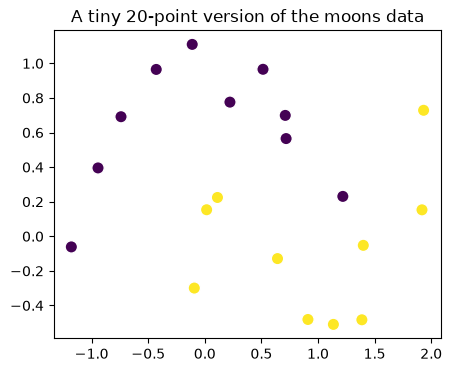

In [8]:
X_toy, y_toy = make_moons(n_samples=20, noise=0.15, random_state=42)

plt.figure(figsize=(5, 4))
plt.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, edgecolors="white", s=80)
plt.title("A tiny 20-point version of the moons data")
plt.show()

One stump, train accuracy: 0.90


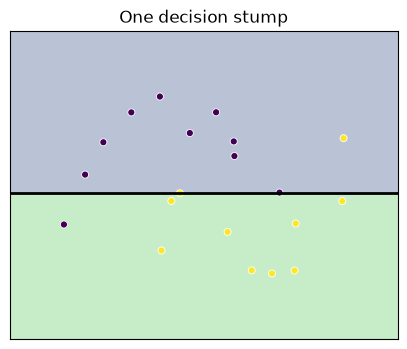

In [9]:
from sklearn.tree import DecisionTreeClassifier

stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_toy, y_toy)
print(f"One stump, train accuracy: {(stump.predict(X_toy) == y_toy).mean():.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
plot_boundary(ax, stump, X_toy, y_toy, "One decision stump")
plt.show()

A single stump (a Decision Tree with `max_depth=1`, one split) gets most points right, but not all. It's a genuinely weak learner: one straight cut, nothing more. Boosting's idea: chain several of these together, each one fixing the last one's mistakes.

### 3.2 AdaBoost, round by round

The idea made concrete: reweight the points a stump gets wrong, fit a new stump on the reweighted data, repeat.

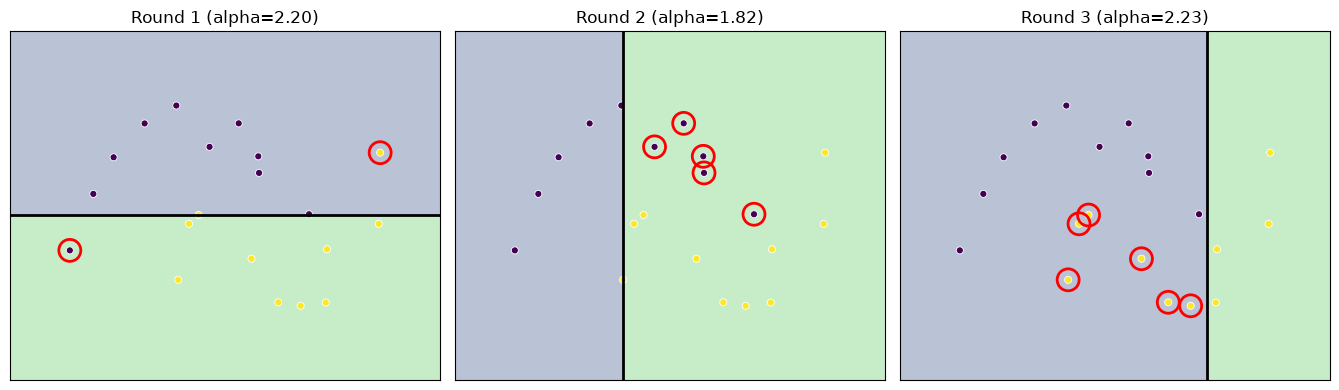

In [10]:
sample_weight = np.full(len(X_toy), 1 / len(X_toy))
stumps, alphas = [], []

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
for round_i in range(3):
    stump = DecisionTreeClassifier(max_depth=1, random_state=42)
    stump.fit(X_toy, y_toy, sample_weight=sample_weight)
    incorrect = stump.predict(X_toy) != y_toy

    error = np.average(incorrect, weights=sample_weight)
    alpha = np.log((1 - error) / error)
    stumps.append(stump)
    alphas.append(alpha)

    ax = axes[round_i]
    plot_boundary(ax, stump, X_toy, y_toy, f"Round {round_i + 1} (alpha={alpha:.2f})")
    ax.scatter(X_toy[incorrect, 0], X_toy[incorrect, 1], s=250, facecolors="none",
               edgecolors="red", linewidths=2)

    sample_weight *= np.exp(alpha * incorrect)
    sample_weight /= sample_weight.sum()

plt.tight_layout()
plt.show()

Circled points are the ones each round's stump gets wrong; those are exactly the ones reweighted heavier for the next round, so round 2's stump is forced to pay attention to what round 1 missed. `alpha`, each stump's eventual vote weight, is bigger for a more accurate round.

In [11]:
def combined_predict(X):
    votes = sum(alpha * np.where(s.predict(X) == 1, 1, -1) for s, alpha in zip(stumps, alphas))
    return (votes > 0).astype(int)

print(f"3 rounds combined, train accuracy: {(combined_predict(X_toy) == y_toy).mean():.2f}")

from sklearn.ensemble import AdaBoostClassifier

ada_toy = AdaBoostClassifier(n_estimators=3, random_state=42).fit(X_toy, y_toy)
print(f"sklearn's AdaBoostClassifier(n_estimators=3), same data: {(ada_toy.predict(X_toy) == y_toy).mean():.2f}")

3 rounds combined, train accuracy: 1.00
sklearn's AdaBoostClassifier(n_estimators=3), same data: 1.00


One stump alone: 90%. Three, combined by weighted vote: 100%, on points no single stump could separate. This manual loop is exactly what `AdaBoostClassifier` does internally, just automated and extended to as many rounds as `n_estimators` asks for.

Now the real dataset: 1,437 training images instead of 20 points, and `AdaBoostClassifier` does all of the above internally, for 100 rounds.

In [12]:
from sklearn.metrics import accuracy_score

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
print(f"AdaBoost test accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")

AdaBoost test accuracy: 0.8306


### 3.3 Gradient Boosting, stage by stage

Same toy set, different mechanic: each stage fits a tree to the *residual error* of the stages before it, rather than reweighting points.

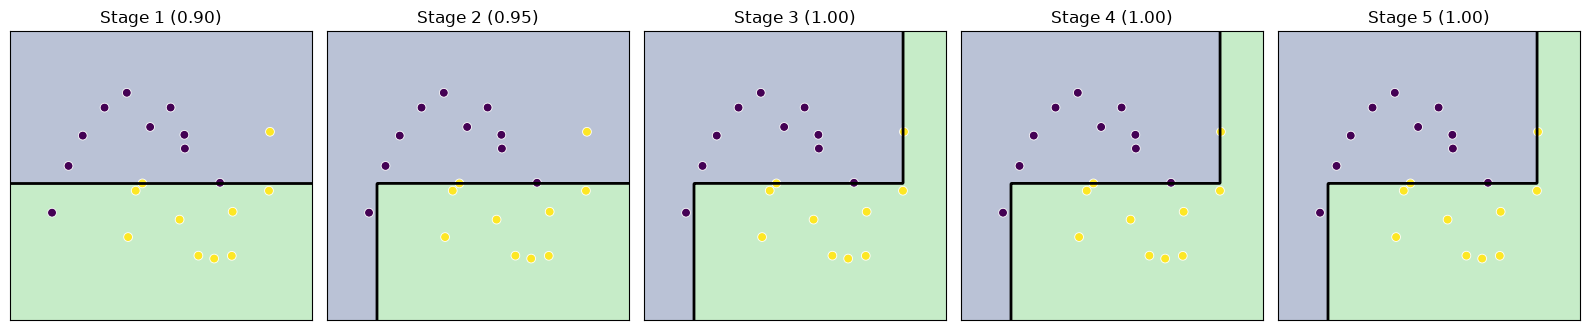

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb_toy = GradientBoostingClassifier(n_estimators=5, max_depth=1, learning_rate=1.0, random_state=42)
gb_toy.fit(X_toy, y_toy)

x_min, x_max = X_toy[:, 0].min() - 0.6, X_toy[:, 0].max() + 0.6
y_min, y_max = X_toy[:, 1].min() - 0.6, X_toy[:, 1].max() + 0.6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
staged_grid_preds = list(gb_toy.staged_predict(grid))
staged_train_preds = list(gb_toy.staged_predict(X_toy))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for stage, ax in enumerate(axes.flat):
    Z = staged_grid_preds[stage].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, edgecolors="white", linewidths=0.6, s=40)
    acc = (staged_train_preds[stage] == y_toy).mean()
    ax.set_title(f"Stage {stage + 1} ({acc:.2f})")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

The boundary bends a little more with every stage, closing in on the points earlier stages still got wrong; by stage 5 it fits all 20 points exactly. `staged_predict` is what makes this picture possible: it replays the model's prediction after each stage was added, without needing to refit anything.

Now the real dataset:

In [14]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print(f"Gradient Boosting test accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")

Gradient Boosting test accuracy: 0.9556


### 3.4 Accuracy as boosting stages accumulate

Both AdaBoost and Gradient Boosting build their ensemble one stage at a time. Tracking test accuracy against `n_estimators` shows that accumulation directly, the same way notebook 1's section 4.2 did for Random Forest's parallel trees. With 10 classes instead of 2, Gradient Boosting in particular fits one tree per class at every stage, so this cell runs slower:

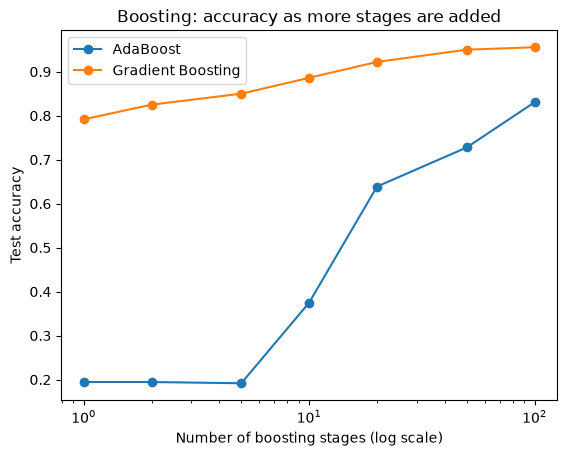

In [15]:
n_list = [1, 2, 5, 10, 20, 50, 100]
ada_acc, gb_acc = [], []
for n in n_list:
    ada_n = AdaBoostClassifier(n_estimators=n, random_state=42).fit(X_train, y_train)
    gb_n = GradientBoostingClassifier(n_estimators=n, random_state=42).fit(X_train, y_train)
    ada_acc.append(accuracy_score(y_test, ada_n.predict(X_test)))
    gb_acc.append(accuracy_score(y_test, gb_n.predict(X_test)))

plt.plot(n_list, ada_acc, marker="o", label="AdaBoost")
plt.plot(n_list, gb_acc, marker="o", label="Gradient Boosting")
plt.xscale("log")
plt.xlabel("Number of boosting stages (log scale)")
plt.ylabel("Test accuracy")
plt.title("Boosting: accuracy as more stages are added")
plt.legend()
plt.show()

### 3.5 Bagging vs. Boosting, visually

Random Forest (bagging) vs. AdaBoost and Gradient Boosting (boosting), same synthetic data:

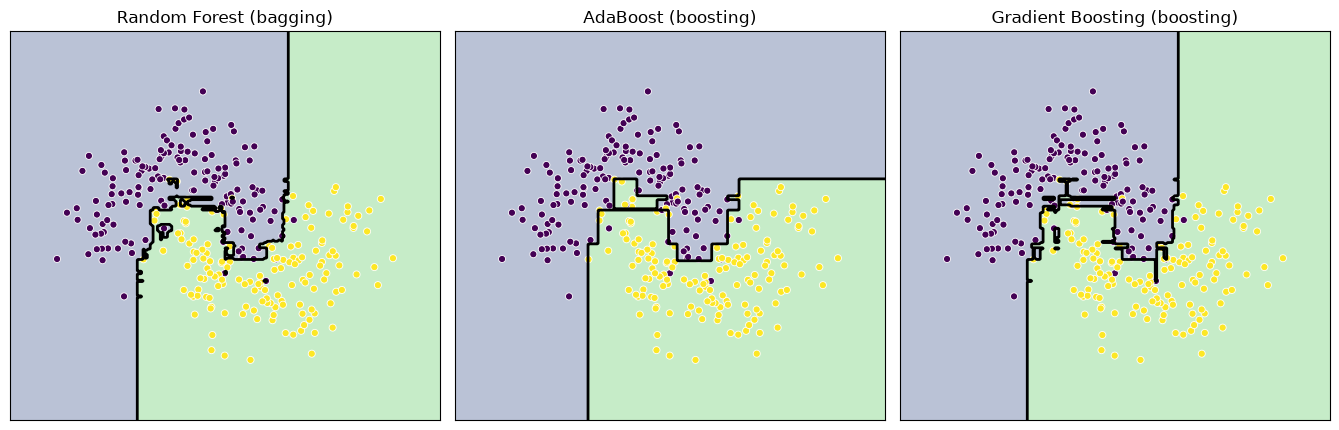

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_moons = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_moons, y_moons)
ada_moons = AdaBoostClassifier(n_estimators=100, random_state=42).fit(X_moons, y_moons)
gb_moons = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_moons, y_moons)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
plot_boundary(axes[0], rf_moons, X_moons, y_moons, "Random Forest (bagging)")
plot_boundary(axes[1], ada_moons, X_moons, y_moons, "AdaBoost (boosting)")
plot_boundary(axes[2], gb_moons, X_moons, y_moons, "Gradient Boosting (boosting)")
plt.tight_layout()
plt.show()

Similar boundary quality, from very different ensemble-building strategies. `XGBoost`, `LightGBM`, and `CatBoost` are optimized gradient boosting implementations, same `fit`/`predict` pattern, installed separately.

## 4. Summary

- **Ensemble Learning**: combine many weak models so mistakes cancel out. **Bagging** (parallel) vs. **Boosting** (sequential).
- **AdaBoost** reweights samples the ensemble gets wrong, and gives each round's tree a vote weight based on how well it did; traced by hand on 20 points, 3 rounds took a single stump's 90% to a perfect 100%.
- **Gradient Boosting** fits the residual error instead, directly minimizing a loss that fell to 100% training accuracy within 5 stages on the same toy set; slower on the real dataset, with 10 classes to fit per stage.
- Similar boundary quality from very different strategies. `XGBoost`/`LightGBM`/`CatBoost` are the optimized, production versions of the same idea.

Notebook 3: a completely different angle on the boundary: Support Vector Machines.